In [4]:
import pandas as pd
import os
from pathlib import Path
import glob
import re
import numpy as np
import xarray as xr 

### Prepare deforestation maps for fig 1

In [5]:
# Use the local ERA5 temperature subset as the 0.5 by 0.5 degree grid template.
# This makes the notebook runnable locally without AMAZON_DATA_DIR.
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "02_bioclimatic_variables" / "local" / "data" / "T_southamerica_base_period_historic_local.nc").exists()
)

T_ERA5_base_year_1980_2014_path = (
    repository_root
    / "02_bioclimatic_variables"
    / "local"
    / "data"
    / "T_southamerica_base_period_historic_local.nc"
)
T_ERA5_base_year_1980_2014 = xr.open_dataset(T_ERA5_base_year_1980_2014_path)


In [6]:
# Use the local ERA5 template coordinates and select the Amazon extent.
lat_coord_ERA5 = T_ERA5_base_year_1980_2014.latitude.values
lon_coord_ERA5 = T_ERA5_base_year_1980_2014.longitude.values

lon_min, lat_min, lon_max, lat_max = -80, -20, -50, 5


In [7]:
# Deforestation maps

# base path 
base = repository_root / "07_postprocess_data" / "local" / "deforestation_maps" / "regridded_deforestation_scenarios"

# txt path 
txt_path = base / "deforestation_all_BaU_2005.txt"
txt_files = [str(path) for path in sorted(base.glob("deforestation_all_BaU_*.txt"))]

years = []
data_list = []

for f in txt_files:

    year = int(re.findall(r"(\d{4})", f)[-1])
    years.append(year)

    df = pd.read_csv(f, sep=r"\s+", header = None, names = ["lon", "lat", "defor"])
    data_list.append(df)


lons = sorted(data_list[0]["lon"].unique())
lats = sorted(data_list[0]["lat"].unique())

# Convert each dataframe to 2 D array
grids = []

for df in data_list:
    grid = df.pivot_table(index="lat", columns="lon", values="defor").reindex(index=lats, columns=lons)
    grids.append(grid.values)

ds = xr.Dataset(
    {
     "deforestation": (("year","latitude", "longitude"), grids)   
    },
    coords={
        "year": years,
        "latitude": lats,
        "longitude": lons
    }
)

In [8]:
# Calculate mean
ds_2030_2044 = ds.sel(year=slice(2030,2044)).mean("year")
# Deforestation stays the same starting from 2050 on 
ds_2050_2069 = ds.sel(year=2050)
ds_2080_2099 = ds.sel(year=2050)

# Interpolate on 0.5 time 0.5 resolution
ds_2030_2044_linear = ds_2030_2044.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="linear")
ds_2050_2069_linear = ds_2050_2069.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="linear")
ds_2080_2099_linear = ds_2080_2099.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="linear")

# Interpolate on 0.5 time 0.5 resolution
ds_2030_2044_nearest = ds_2030_2044.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="nearest")
ds_2050_2069_nearest = ds_2050_2069.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="nearest")
ds_2080_2099_nearest = ds_2080_2099.interp(latitude=lat_coord_ERA5, longitude=lon_coord_ERA5, method="nearest")

ds_2030_2044 = ds_2030_2044_linear.combine_first(ds_2030_2044_nearest)
ds_2050_2069  = ds_2050_2069_linear.combine_first(ds_2050_2069_nearest)
ds_2080_2099  = ds_2080_2099_linear.combine_first(ds_2080_2099_nearest)

# Binarize
ds_2030_2044_bin = (ds_2030_2044["deforestation"] >= .5).astype(int).where(~np.isnan(ds_2030_2044))
ds_2050_2069_bin = (ds_2050_2069["deforestation"] >= .5).astype(int).where(~np.isnan(ds_2050_2069))
ds_2080_2099_bin = (ds_2080_2099["deforestation"] >= .5).astype(int).where(~np.isnan(ds_2080_2099))

# Select only relevant geographical part
ds_2030_2044_bin = ds_2030_2044_bin.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)

ds_2050_2069_bin = ds_2050_2069_bin.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)

ds_2080_2099_bin = ds_2080_2099_bin.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)

In [9]:
# Save the local Figure 1 inputs directly to the plotting-data folder.
save_folder = repository_root / "08_figures" / "main_figures" / "figure_1" / "local" / "data"
save_folder.mkdir(parents=True, exist_ok=True)

ds_2030_2044_bin.to_netcdf(save_folder / "binary_defors_map_2030_2044.nc")
ds_2050_2069_bin.to_netcdf(save_folder / "binary_defors_map_2050_2069.nc")
ds_2080_2099_bin.to_netcdf(save_folder / "binary_defors_map_2080_2099.nc")


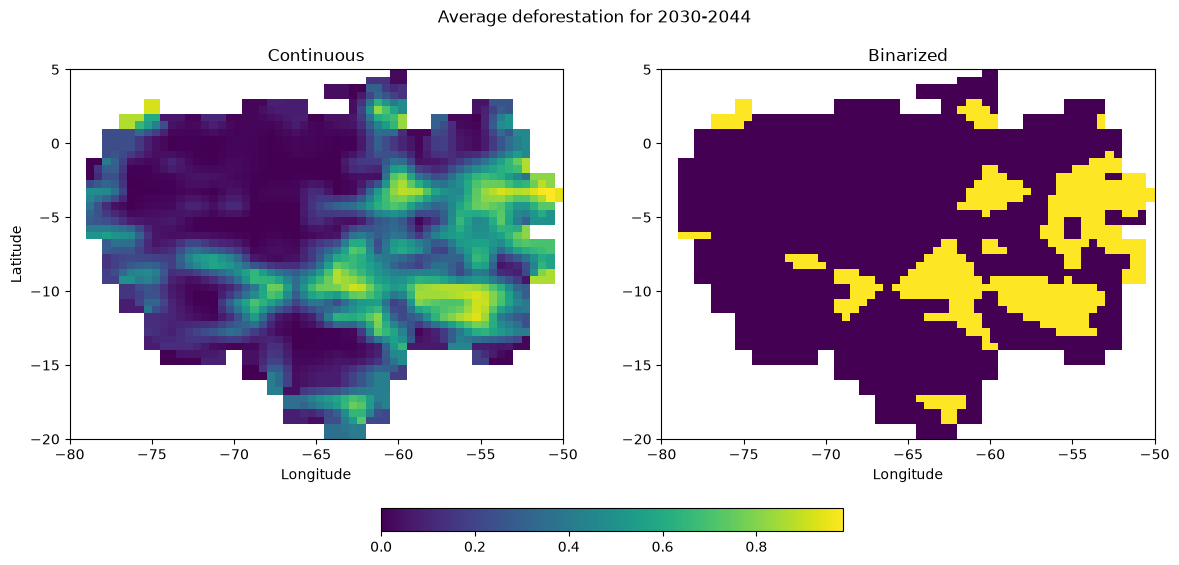

In [11]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1,2, figsize=(14,6))

da = ds_2030_2044['deforestation'].sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)
da_bin = ds_2030_2044_bin['deforestation']

im0 = ax[0].pcolormesh(
    da.longitude,
    da.latitude,
    da,
    shading="auto"
)

ax[1].pcolormesh(
    da_bin.longitude,
    da_bin.latitude,
    da_bin,
    shading="auto"
)


ax[0].set_xlabel("Longitude")
ax[1].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_title("Continuous")
ax[1].set_title("Binarized")

cbar = fig.colorbar(
    im0,
    ax=ax,
    orientation="horizontal",
    fraction=0.05
)

plt.suptitle("Average deforestation for 2030-2044")
plt.show()